**IMPORT LIBRARIES**

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score,confusion_matrix ,classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


**LOAD THE DATA**

In [45]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Loading Dataset**

In [46]:
# laod the dataset to a pandas dataframe
data = pd.read_csv("/content/Rainfall.csv")

In [47]:
data.head(10)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
0,1,1025.9,19.9,18.3,16.8,13.1,72,49,yes,9.3,80.0,26.3
1,2,1022.0,21.7,18.9,17.2,15.6,81,83,yes,0.6,50.0,15.3
2,3,1019.7,20.3,19.3,18.0,18.4,95,91,yes,0.0,40.0,14.2
3,4,1018.9,22.3,20.6,19.1,18.8,90,88,yes,1.0,50.0,16.9
4,5,1015.9,21.3,20.7,20.2,19.9,95,81,yes,0.0,40.0,13.7
5,6,1018.8,24.3,20.9,19.2,18.0,84,51,yes,7.7,20.0,14.5
6,7,1021.8,21.4,18.8,17.0,15.0,79,56,no,3.4,30.0,21.5
7,8,1020.8,21.0,18.4,16.5,14.4,78,28,no,7.7,60.0,14.3
8,9,1020.6,18.9,18.1,17.1,14.3,78,79,no,3.3,70.0,39.3
9,10,1017.5,18.5,18.0,17.2,15.5,85,91,yes,0.0,70.0,37.7


In [48]:
# Load dataset
data = pd.read_csv("Rainfall.csv")

# Show first 5 rows
print(data.head())

   day  pressure   maxtemp  temparature  mintemp  dewpoint  humidity   cloud   \
0    1     1025.9     19.9         18.3     16.8      13.1         72      49   
1    2     1022.0     21.7         18.9     17.2      15.6         81      83   
2    3     1019.7     20.3         19.3     18.0      18.4         95      91   
3    4     1018.9     22.3         20.6     19.1      18.8         90      88   
4    5     1015.9     21.3         20.7     20.2      19.9         95      81   

  rainfall  sunshine           winddirection  windspeed  
0      yes       9.3                    80.0       26.3  
1      yes       0.6                    50.0       15.3  
2      yes       0.0                    40.0       14.2  
3      yes       1.0                    50.0       16.9  
4      yes       0.0                    40.0       13.7  


**INFORMATION ABOUT DATA**

In [49]:
print(type(data))

<class 'pandas.core.frame.DataFrame'>


In [50]:
data.shape

(366, 12)

In [51]:
data.tail(10)

,day,pressure,maxtemp,temparature,mintemp,dewpoint,humidity,cloud,rainfall,sunshine,winddirection,windspeed
356,22,1020.3,20.6,19.9,18.7,17.6,87,88,yes,0.3,60.0,27.3
357,23,1017.8,22.3,21.1,19.8,19.6,91,79,yes,0.0,40.0,15.0
358,24,1016.8,24.7,22.3,21.1,20.7,91,70,yes,6.0,40.0,9.4
359,25,1020.4,21.4,18.2,16.1,13.5,75,89,yes,0.7,10.0,27.6
360,26,1020.6,19.7,17.9,16.9,13.3,74,87,no,0.6,30.0,21.6
361,27,1022.7,18.8,17.7,16.9,15.0,84,90,yes,0.0,30.0,18.4
362,28,1026.6,18.6,17.3,16.3,12.8,75,85,yes,1.0,20.0,25.9
363,29,1025.9,18.9,17.7,16.4,13.3,75,78,yes,4.6,70.0,33.4
364,30,1025.3,19.2,17.3,15.2,13.3,78,86,yes,1.2,20.0,20.9
365,31,1026.4,20.5,17.8,15.5,13.0,74,66,no,5.7,20.0,23.3


In [52]:
data["day"].unique()


array([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17,
       18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31])

In [53]:
data.columns

Index(['day', 'pressure ', 'maxtemp', 'temparature', 'mintemp', 'dewpoint',
       'humidity ', 'cloud ', 'rainfall', 'sunshine', '         winddirection',
       'windspeed'],
      dtype='object')

In [54]:
print(data.info())
print(data.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 366 entries, 0 to 365
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   day                     366 non-null    int64  
 1   pressure                366 non-null    float64
 2   maxtemp                 366 non-null    float64
 3   temparature             366 non-null    float64
 4   mintemp                 366 non-null    float64
 5   dewpoint                366 non-null    float64
 6   humidity                366 non-null    int64  
 7   cloud                   366 non-null    int64  
 8   rainfall                366 non-null    object 
 9   sunshine                366 non-null    float64
 10           winddirection  365 non-null    float64
 11  windspeed               365 non-null    float64
dtypes: float64(8), int64(3), object(1)
memory usage: 34.4+ KB
None
              day    pressure      maxtemp  temparature     mintemp  \
count  366.000

In [55]:
print(data["rainfall"].value_counts())

rainfall
yes    249
no     117
Name: count, dtype: int64


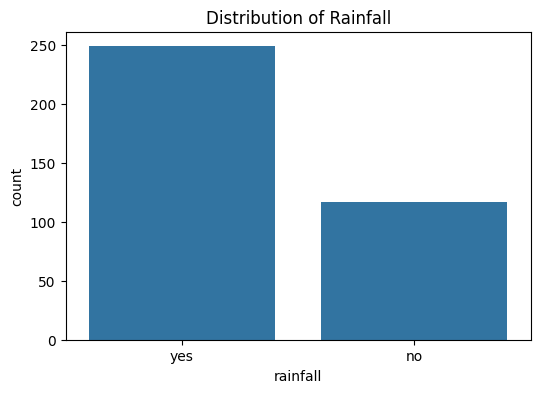

In [56]:
plt.figure(figsize=(6, 4))
sns.countplot(x="rainfall", data=data)
plt.title("Distribution of Rainfall")
plt.show()

**PREPROCESSING OF DATA**

In [57]:
# Check missing values
print("Missing values before processing 'rainfall':")
print(data.isnull().sum())

# Standardize 'rainfall' column to lowercase
data['rainfall'] = data['rainfall'].astype(str).str.lower()

# Convert 'rainfall' column to numerical (1 for 'yes', 0 for 'no')
# Using np.where is more robust; values not 'yes' or 'no' will explicitly become NaN.
data['rainfall'] = np.where(data['rainfall'] == 'yes', 1, np.where(data['rainfall'] == 'no', 0, np.nan))

# Print value counts to diagnose content after initial conversion
print("\nValue counts for 'rainfall' after initial conversion:")
print(data['rainfall'].value_counts(dropna=False))

# Fill any remaining NaN values in 'rainfall'. Since it's a binary target, filling with the mode is suitable.
if data['rainfall'].isnull().any():
    mode_value = data['rainfall'].mode()
    if not mode_value.empty: # Check if mode() returned anything
        print(f"Filling {data['rainfall'].isnull().sum()} NaNs in 'rainfall' with mode: {int(mode_value[0])}")
        data['rainfall'] = data['rainfall'].fillna(mode_value[0])
    else:
        # Fallback if mode is empty (e.g., all values are NaN after conversion)
        print(f"Warning: 'rainfall' column contains only NaNs after conversion or has no mode. Filling with 0 (no rain).")
        data['rainfall'] = data['rainfall'].fillna(0)

# Fill missing numerical values in other columns with their respective means
# This should be done on the DataFrame after the 'rainfall' column is numeric
data = data.fillna(data.mean(numeric_only=True))

# Check missing values after processing
print("\nMissing values after processing:")
print(data.isnull().sum())

Missing values before processing 'rainfall':
day                       0
pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    1
windspeed                 1
dtype: int64

Value counts for 'rainfall' after initial conversion:
rainfall
1.0    249
0.0    117
Name: count, dtype: int64

Missing values after processing:
day                       0
pressure                  0
maxtemp                   0
temparature               0
mintemp                   0
dewpoint                  0
humidity                  0
cloud                     0
rainfall                  0
sunshine                  0
         winddirection    0
windspeed                 0
dtype: int64


**DEVIDE THE DATA**

In [58]:
X = data.drop('rainfall', axis=1)
y = data['rainfall']

# Drop rows where y is NaN and align X
combined = pd.concat([X, y], axis=1).dropna(subset=['rainfall'])
X = combined.drop('rainfall', axis=1)
y = combined['rainfall']

In [59]:
data["rainfall"].unique()

array([1., 0.])

In [60]:
print(data["rainfall"].value_counts())

rainfall
1.0    249
0.0    117
Name: count, dtype: int64


**SPLIT THE DATA**

In [61]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2,      # 20% data for testing

)

**USING LOGISTIC REGRESSION MODEL**

In [62]:
model = LogisticRegression()

In [63]:
model.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [64]:
y_pred = model.predict(X_test)

CHECKING ACCURACY

In [65]:
accuracy = accuracy_score(y_test, y_pred)
conf_matrix = confusion_matrix(y_test, y_pred)

In [66]:
print("Accuracy:", accuracy)
print("Confusion Matrix:\n", conf_matrix)


Accuracy: 0.8648648648648649
Confusion Matrix:
 [[17  6]
 [ 4 47]]


In [67]:
input_data = (1015.9, 19.9, 95, 81, 0.0, 40.0, 13.7)

input_df = pd.DataFrame([input_data], columns=['pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine','winddirection', 'windspeed'])

In [68]:
input_data = (1, 1015.9, 19.9, 20.7, 20.2, 19.9, 95, 81, 0.0, 40.0, 13.7) # Example: added 'day', 'maxtemp', 'temparature', 'mintemp' values

# Retrieve the correct feature names from the X DataFrame
feature_names = X.columns.tolist()

input_df = pd.DataFrame([input_data], columns=feature_names)
prediction = model.predict(input_df)

if prediction[0] == 1:
    print("It is likely to rain.")
else:
    print("It is not likely to rain.")

It is likely to rain.


**USING DECISION TREE CLASSIFIER**

In [69]:
dt_model = DecisionTreeClassifier()

In [70]:
dt_model.fit(X_train, y_train)

DecisionTreeClassifier()

In [71]:
y_pred = dt_model.predict(X_test)

CHECKING ACCURACY

In [72]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.7432432432432432
Confusion Matrix:
[[16  7]
 [12 39]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.57      0.70      0.63        23
         1.0       0.85      0.76      0.80        51

    accuracy                           0.74        74
   macro avg       0.71      0.73      0.72        74
weighted avg       0.76      0.74      0.75        74



In [73]:
input_data = (1, 1015.9, 19.9, 20.7, 20.2, 19.9, 95, 81, 0.0, 40.0, 13.7) # Example: added 'day', 'maxtemp', 'temparature', 'mintemp' values

# Retrieve the correct feature names from the X DataFrame
feature_names = X.columns.tolist()

input_df = pd.DataFrame([input_data], columns=feature_names)
prediction = model.predict(input_df)

if prediction[0] == 1:
    print("It is likely to rain.")
else:
    print("It is not likely to rain.")

It is likely to rain.


**USING RANDOM FOREST CLASSIFIER MODEL**

In [74]:
rf_model = RandomForestClassifier()


In [75]:
rf_model.fit(X_train, y_train)

RandomForestClassifier()

In [76]:
y_pred = rf_model.predict(X_test)

CHECKING ACCURACY

In [77]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.8108108108108109
Confusion Matrix:
[[16  7]
 [ 7 44]]
Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.70      0.70        23
         1.0       0.86      0.86      0.86        51

    accuracy                           0.81        74
   macro avg       0.78      0.78      0.78        74
weighted avg       0.81      0.81      0.81        74



In [78]:
input_data = (1, 1015.9, 19.9, 20.7, 20.2, 19.9, 95, 81, 0.0, 40.0, 13.7) # Example: added 'day', 'maxtemp', 'temparature', 'mintemp' values

# Retrieve the correct feature names from the X DataFrame
feature_names = X.columns.tolist()

input_df = pd.DataFrame([input_data], columns=feature_names)
prediction = model.predict(input_df)

if prediction[0] == 1:
    print("It is likely to rain.")
else:
    print("It is not likely to rain.")

It is likely to rain.


In [79]:
import pickle
pickle.dump(model,open("RAIN PREEDICTOR.pkl",'wb'))

In [80]:
model= pickle.load(open("RAIN PREEDICTOR.pkl",'rb'))